## 1. Import Necessary Packages

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms
import torchaudio
import numpy as np
import kaggle
import matplotlib.pyplot as plt
import pandas as pd
import librosa
from pathlib import Path
from mutagen.mp3 import MP3
from mutagen import MutagenError
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from collections import Counter

## 2. Define Default Values

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataFolder = './data'
dataPath = Path(dataFolder)

## 3. Download Data
In this, I will be using the [FMA Medium dataset](https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium).
Ensure that you have set your kaggle api token as an environment variable (KAGGLE_API_TOKEN) amd have enough storage for this dataset (34.26 GB).
I made this automatically check if the `./data` folder exists and skips the download if it does to prevent repeated downloadeds, to avoid this, just delete the `./data` folder when you need to redownload.

In [3]:
if not dataPath.exists():
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files('imsparsh/fma-free-music-archive-small-medium', path=dataFolder, unzip=True)

## 4. Clean and Prepare Data
Get genre names and create Dataset class to read the files. Rather than loading all 34GB into memory, this will pull the files at read time.

### Load Metadata

In [4]:
datasetPath = Path(f'{dataFolder}/fma_medium/fma_medium')
numGenres = sum(1 for x in datasetPath.iterdir() if x.is_dir())
genresNumbered = [i for i in range(numGenres)]
print(f'Number of genres: {numGenres}')
df = pd.read_csv(f'{dataFolder}/fma_metadata/genres.csv')
print(df.describe)
genres = df['title'][:numGenres]
# Make sure there are not more file genres than metadata genres
assert(genres.shape[0] == numGenres)

Number of genres: 156
<bound method NDFrame.describe of      genre_id  #tracks  parent          title  top_level
0           1     8693      38    Avant-Garde         38
1           2     5271       0  International          2
2           3     1752       0          Blues          3
3           4     4126       0           Jazz          4
4           5     4106       0      Classical          5
..        ...      ...     ...            ...        ...
158      1032       60     102        Turkish          2
159      1060       30      46          Tango          2
160      1156       26     130           Fado          2
161      1193       72     763      Christmas         38
162      1235    14938       0   Instrumental       1235

[163 rows x 5 columns]>


### Reduce Genres
songs per genre are variable, so to ensure that the dataset is not too noisy from genres with only a couple songs, make sure there are enough song for each genre to learn.

In [5]:
def is_valid_mp3(path: str) -> bool:
    try:
        audio = MP3(path)
        return audio.info.length > 0
    except (MutagenError, Exception):
        return False
        
def load_dataset(dir_path: str, num_workers: int = 0) -> tuple[list[str], list[str]]:
        """
        Loads dataset file paths and labels into memory.
        Returns list of all the paths
        """
        global numGenres, genresNumbered
        # Collect all video paths and connect them to their label
        label_dirs = [d for d in dir_path.iterdir() if d.is_dir()]
        all_files = []

        for dir in label_dirs:
            label_idx = int(dir.name)
            for item in dir.iterdir():
                # Only care about files that are .mp3
                if item.is_file() and item.suffix == '.mp3':
                    all_files.append((item.resolve(), label_idx))

        video_labels = []
        video_paths = []

        def validate(args):
            path, label = args
            return (path, label) if is_valid_mp3(path) else None
        
        # Use worker threads if wanted, else use main thread
        if num_workers > 0:
            with ThreadPoolExecutor(max_workers=num_workers) as executor:
                futures = {
                    executor.submit(validate, f): f for f in all_files
                }
                for future in tqdm(as_completed(futures), total=len(futures), desc="Validating"):
                    result = future.result()
                    if result:
                        path, label = result
                        video_labels.append(label)
                        video_paths.append(path)
        else:
            for f in all_files:
                result = validate(f)
                if validate(f):
                    path, label = result
                    video_labels.append(label)
                    video_paths.append(path)

        count = Counter(video_labels)
        invalid = set()
        for key, amt in count.items():
            if amt < 200:
                invalid.add(key)

        # Update number of genres, genre mapping, and labels to be [0, actual number of genres]
        numGenres -= len(invalid)
        genresNumbered = [genre for genre in genresNumbered if genre not in invalid]
        newGenreLabel = {genre: i for i, genre in enumerate(genresNumbered)}

        # Update path first, since it relies on using the current index of video_labels
        video_paths = [val for i, val in enumerate(video_paths) if video_labels[i] not in invalid]
        video_labels = [newGenreLabel[val] for val in video_labels if val not in invalid]

        return video_labels, video_paths

video_labels, video_paths = load_dataset(datasetPath, num_workers=4)
print(f"After processing dataset, {numGenres} genres kept.")

Validating: 100%|██████████| 25000/25000 [00:20<00:00, 1207.71it/s]


After processing dataset, 40 genres kept.


### Create Custom Dataset

In [6]:
class CustomDataset(Dataset):
    def __init__(
            self, 
            video_labels,
            video_paths, 
            log_mels: bool,
            cqt: bool,
            sample_rate: int = 22050, 
            duration: float = 30.0, 
            n_mels: int = 128,
            n_bins: int = 84,
            bins_per_octave: int = 12,
            n_fft: int = 2048,
            hop_length: int = 512,
            cache_dir: str = None,
            transform: transforms = None,
            num_workers: int = 4
        ):
        # dataset
        self.video_labels = video_labels
        self.video_paths = video_paths
        
        self.transform = transform
        self.num_workers = num_workers

        # spectrogram values
        self.log_mels = log_mels
        self.cqt = cqt
        if not cqt and not log_mels:
            raise ValueError("log_mels or cqt must be true.")
        self.sample_rate = sample_rate
        self.duration = duration
        self.n_mels = n_mels
        self.n_bins = n_bins
        self.bins_per_octave = bins_per_octave
        self.n_fft = n_fft
        self.hop_length = hop_length

        # cache
        self.cache_dir = Path(cache_dir) if cache_dir else None
        if self.cache_dir:
            self.cache_dir.mkdir(parents=True, exist_ok=True)

        # stats
        self.lm_mean = 0.0
        self.lm_std = 0.0
        self.cqt_mean = 0.0
        self.cqt_std = 0.0

    def cache_idx(self, idx: int) -> bool:
        try:
            self.__getitem__(idx)
            return True
        except:
            return False

    def precache_all(self) -> list[str]:
        if not self.cache_dir:
            return []

        N = len(self.video_labels)
        success = [False] * N
        with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
            futures = {
                executor.submit(self.cache_idx, i):i for i in range(N)
            }
            for future in tqdm(as_completed(futures), total=len(futures), desc="Caching"):
                i = futures[future]
                success[i] = future.result()
        self.video_labels = [self.video_labels[i] for i in range(N) if success[i]]
        self.video_paths = [self.video_paths[i] for i in range(N) if success[i]]
        return [i for i in range(N) if not success[i]]

    def mp3_to_log_mel(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.sample_rate * self.duration)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sample_rate,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Normalize to [0,1]
        log_mel = (log_mel-log_mel.min())/(log_mel.max()-log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)

    def mp3_to_cqt(self, path: str) -> np.ndarray:
        audio, _ = librosa.load(
            path,
            sr=self.sample_rate,
            duration=self.duration,
            mono=True
        )

        # Pad clip
        expected_samples = int(self.duration * self.sample_rate)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))

        cqt = librosa.cqt(
            y=audio,
            sr=self.sample_rate,
            n_bins = self.n_bins,
            bins_per_octave = self.bins_per_octave,
            hop_length=self.hop_length,
            fmin=librosa.note_to_hz('C1')
        )

        # Normalize to [0,1]
        log_cqt = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)
        log_cqt = (log_cqt-log_cqt.min())/(log_cqt.max()-log_cqt.min()+1e-8)
        return log_cqt.astype(np.float32)
        

    def load_and_compute_lm(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_lm_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        lm_spec = self.mp3_to_log_mel(path)

        if self.cache_dir:
            np.save(cache_path, lm_spec)

        return lm_spec
    
    def load_and_compute_cqt(self, path: str) -> np.ndarray:
        if self.cache_dir:
            cache_path = self.cache_dir / (Path(path).stem + "_cqt_.npy")
            if cache_path.exists():
                return np.load(cache_path)
        
        cqt_val = self.mp3_to_cqt(path)

        if self.cache_dir:
            np.save(cache_path, cqt_val)
        
        return cqt_val

    def __len__(self) -> int:
        return len(self.video_labels)
    
    def __getitem__(self, idx: int) -> np.ndarray:
        label = self.video_labels[idx]
        vid = self.video_paths[idx]
        
        if self.log_mels and self.cqt:
            lm_spect = self.load_and_compute_lm(vid)
            cqt_spect = self.load_and_compute_cqt(vid)

            # Get mean and std (use if dataset updated)
            self.lm_mean += lm_spect.reshape(-1).mean()
            self.lm_std += lm_spect.reshape(-1).std()
            self.cqt_mean += cqt_spect.reshape(-1).mean()
            self.cqt_std += cqt_spect.reshape(-1).mean()

            cqt_spect_padded = np.pad(cqt_spect, ((0, self.n_mels - self.n_bins), (0, 0)))

            # Stack lm and cqt
            stacked_output = np.stack([lm_spect, cqt_spect_padded], axis=0)
            stacked_output = torch.tensor(stacked_output, dtype=torch.float32)
            
            if self.transform:
                stacked_output = self.transform(stacked_output)
            return stacked_output, label
        elif self.log_mels:
            lm_spect = self.load_and_compute_lm(vid)
            lm_spect = torch.tensor(lm_spect, dtype=torch.float32).unsqueeze(0)

            if self.transform:
                lm_spect = self.transform(lm_spect)
            return lm_spect, label
        else:
            cqt_spect = self.load_and_compute_cqt(vid)
            cqt_spect = torch.tensor(cqt_spect, dtype=torch.float32).unsqueeze(0)

            if self.transform:
                cqt_spect = self.transform(cqt_spect)
            return cqt_spect, label

### Load Dataset

In [19]:
# Calculated mean and std values [lm_val, cqt_val]
transform = transforms.Compose([
    transforms.Normalize(
        mean=[0.36205917596817017, 0.3663458824157715],
        std=[0.10241946578025818, 0.37519213557243347]
    ),
    torchaudio.transforms.FrequencyMasking(freq_mask_param=30),   # mask up to 30 frequency bins
    torchaudio.transforms.TimeMasking(time_mask_param=100),        # mask up to 100 time frames
    torchaudio.transforms.TimeMasking(time_mask_param=100),        # apply twice for stronger effect

    transforms.RandomErasing(p=0.3),
])
cache = './cache'
ds = CustomDataset(video_labels, video_paths, True, True, cache_dir=cache, transform=transform)

# Precaching will help to validate that all the .mp3 files are accessible.
ds.precache_all()

test_ds, train_ds, val_ds = random_split(ds, lengths=[0.15, 0.70, 0.15])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

Caching:  51%|█████     | 4779/9439 [00:19<00:20, 228.79it/s]C:\Users\Dylan Lederman\AppData\Local\Temp\ipykernel_21400\2796758554.py:75: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(
Caching: 100%|██████████| 9439/9439 [00:36<00:00, 261.65it/s]


In [ ]:
# Gets mean and std, not needed when already computed
print(len(ds))
mean = (np.array([ds.lm_mean, ds.cqt_mean]) / len(ds.video_paths)).tolist()
std = (np.array([ds.lm_std, ds.cqt_std]) / len(ds.video_paths)).tolist()
print(f"mean: {mean}, std: {std}")

9434
mean: [0.4089151918888092, 0.4403897225856781], std: [0.13258467614650726, 0.4474632441997528]


### View dataset
*Do not run if using multiple workers

Label: 19 — Shape: torch.Size([2, 128, 1292])


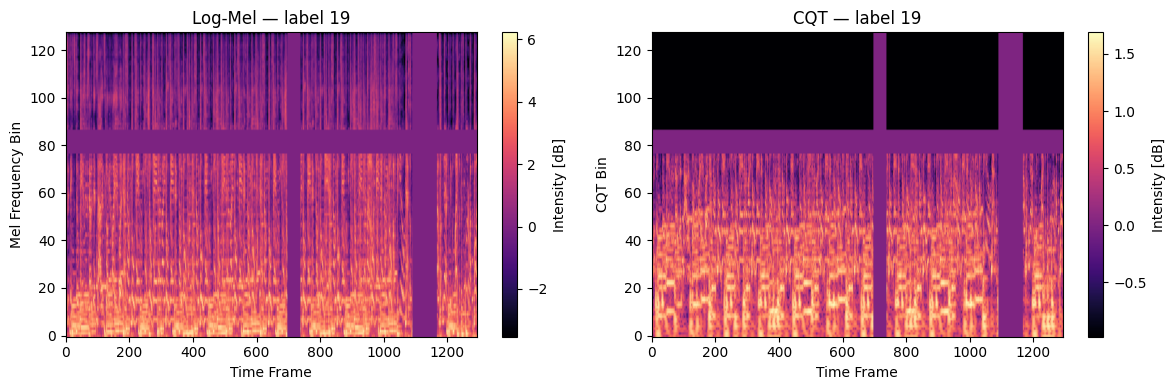

Label: 16 — Shape: torch.Size([2, 128, 1292])


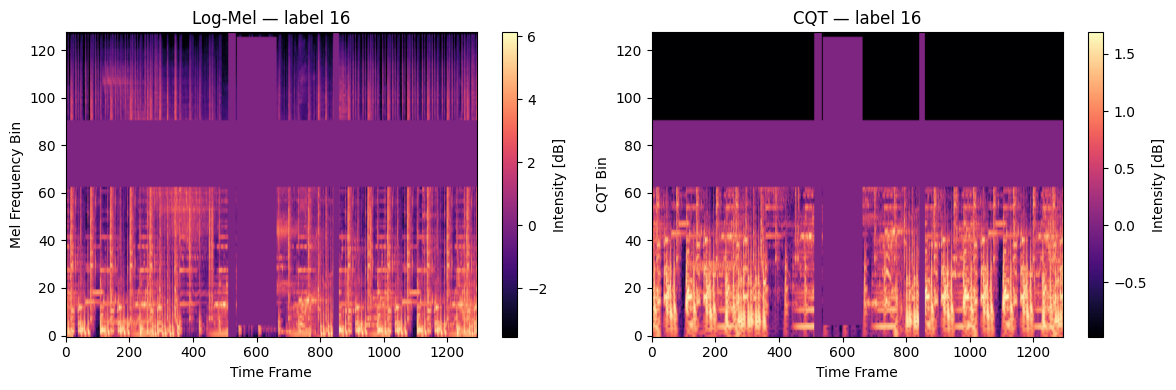

In [20]:
# These will be transformed (normalized)
def visualize_dataset(loader, ds):
    data = next(iter(loader))
    inputs, labels = data
    N = 2

    for i in range(N):
        input = inputs[i]   # (C, 128, T) where C is 1 or 2
        label = labels[i].item()
        print(f"Label: {label} — Shape: {input.shape}")

        n_channels = input.shape[0]
        fig, axes = plt.subplots(1, n_channels, figsize=(6 * n_channels, 4))

        # Ensure axes is always iterable even if n_channels == 1
        if n_channels == 1:
            axes = [axes]

        titles = []
        if ds.log_mels:
            titles.append(('Log-Mel', 'Mel Frequency Bin'))
        if ds.cqt:
            titles.append(('CQT', 'CQT Bin'))

        for ax, channel, (title, ylabel) in zip(axes, range(n_channels), titles):
            im = ax.imshow(input[channel], origin='lower', aspect='auto', cmap='magma')
            ax.set_ylabel(ylabel)
            ax.set_xlabel('Time Frame')
            ax.set_title(f'{title} — label {label}')
            fig.colorbar(im, ax=ax, label='Intensity [dB]')

        plt.tight_layout()
        plt.show()

visualize_dataset(train_loader, ds)

## 5. Create the Network

### Model

In [21]:
model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
# Replace first conv — pretrained weights expect 3 channels
model.conv1 = torch.nn.Conv2d(2, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(p=0.5),
    torch.nn.Linear(model.fc.in_features, numGenres)  # 156 genres-number of removed
)

## 6. Train the Network

### Testing and Accuracy Functions

In [22]:
def check_accuracy(loader, model) -> float:
    print("Checking Accuracy")
    model = model.to(device=device)
    num_correct = num_samples = 0
    model.eval()
    with torch.no_grad():
        for input, label in loader:
            x = input.to(device=device)
            y = label.to(device=device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(f"Got {num_correct} / {num_samples} with accuracy {float(num_correct)/float(num_samples)*100:.2f}")
    return float(num_correct)/float(num_samples)

def train_model(train_loader, valid_loader, model, optimizer, loss_fn, epochs) -> tuple[list[float], list[float], list[float]]:
    model = model.to(device=device)
    train_accuracy = []
    losses = []
    validation_acc = []
    for e in range(epochs):
        epoch_loss = 0.0
        num_batches = 0
        num_right = 0
        num_total = 0
        for input, label in tqdm(train_loader, total=len(train_loader), desc="Batch"):
            model.train()
            x = input.to(device=device)
            y = label.to(device=device)

            score = model(x)
            loss = loss_fn(score, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            

            actual = torch.argmax(score, dim=1)
            
            num_right += sum([1 if actual[i] == y[i] else 0 for i in range(len(y))])
            num_total += y.size(0)

            epoch_loss += loss.item()
            num_batches += 1
        avg_loss = epoch_loss / num_batches

        print(f"Epoch {e+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {num_right}/{num_total}")
        val_acc = check_accuracy(valid_loader, model)
        print()

        validation_acc.append(val_acc)
        losses.append(loss.item())
        train_accuracy.append(float(num_right)/float(num_total))
    return train_accuracy, losses, validation_acc

In [23]:
# Set device
model = model.to(device)

# Define functions and values to be used for training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = 20
torch.cuda.empty_cache()
# Train the model
train_accuracy, losses, validation_acc = train_model(train_loader, val_loader, model, optimizer, loss_fn, epochs)

Batch: 100%|██████████| 413/413 [01:53<00:00,  3.65it/s]


Epoch 1/20, Loss: 3.7733, Accuracy: 226/6603
Checking Accuracy
Got 89 / 1415 with accuracy 6.29



Batch: 100%|██████████| 413/413 [01:49<00:00,  3.77it/s]


Epoch 2/20, Loss: 3.6638, Accuracy: 331/6603
Checking Accuracy
Got 136 / 1415 with accuracy 9.61



Batch: 100%|██████████| 413/413 [01:44<00:00,  3.97it/s]


...

Epoch 18/20, Loss: 1.3152, Accuracy: 4438/6603
Checking Accuracy
Got 355 / 1415 with accuracy 25.09



Batch: 100%|██████████| 413/413 [01:44<00:00,  3.96it/s]


Epoch 19/20, Loss: 1.1413, Accuracy: 4739/6603
Checking Accuracy
Got 361 / 1415 with accuracy 25.51



Batch: 100%|██████████| 413/413 [01:46<00:00,  3.88it/s]


Epoch 20/20, Loss: 0.9209, Accuracy: 5178/6603
Checking Accuracy
Got 373 / 1415 with accuracy 26.36



### Visualize Training Results

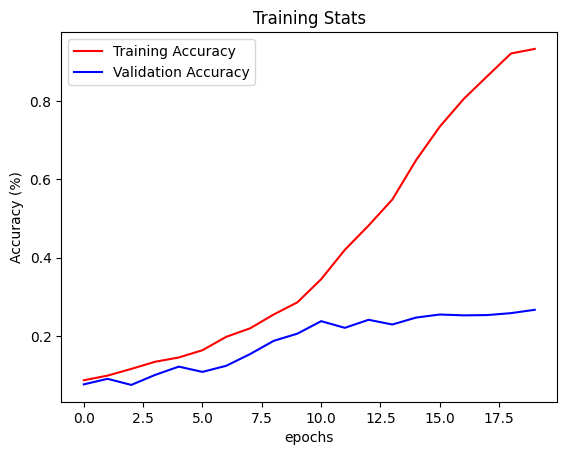

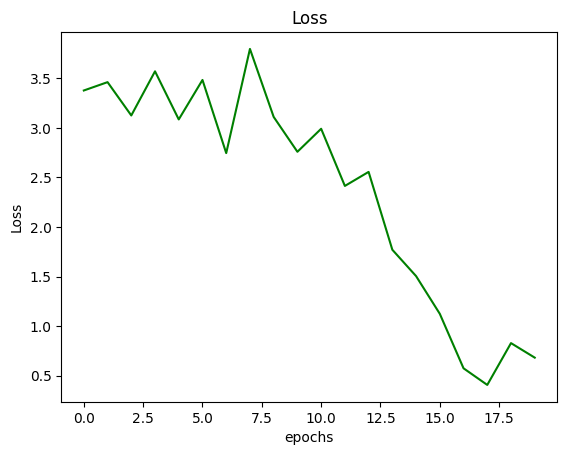

In [ ]:
train_accuracy, losses, validation_acc
plt.plot(train_accuracy, label="Training Accuracy", color='red')
plt.plot(validation_acc, label="Validation Accuracy", color='blue')
plt.title("Training Stats")
plt.xlabel("epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()
plt.plot(losses, label="Training Loss", color='green')
plt.title("Loss")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.show()

## 7. Test the Network

In [ ]:
train_acc = check_accuracy(test_loader, model)
print(f"Testing accuracy: {train_acc:.2f}")